### **<u>Acknowledgement Statement by student:</u>**

I acknowledge that I have  **<u>only used</u>** GAITs (e.g., ChatGPT) in drafting and proofreading this assignment, which is permitted in the assignment instructions.


## SECTION 1: DATA CLEANING

### 1.1. Import necessary libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

### 1.2. Understand general information of dataset

In [2]:
# Import dataset
df = pd.read_csv('customer_shopping_data.csv')

In [3]:
# Check the number of columns and rows
df.shape

(99461, 10)

**Dataset has 99461 rows and 10 columns.**

In [4]:
# Check 5 first rows of dataset
df.head()

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,8/05/2022,Kanyon
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,12/12/2021,Forum Istanbul
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,11/09/2021,Metrocity
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,5/16/2021,Metropol AVM
4,I337046,C189076,Female,53,Books,4,60.60,Cash,10/24/2021,Kanyon


### 1.3. Handle missing values

In [5]:
# Find total null values in each column
missing_values_per_column = df.isnull().sum()
print("Missing values per column:\n", missing_values_per_column)

Missing values per column:
 invoice_no        0
customer_id       0
gender            0
age               0
category          0
quantity          0
price             2
payment_method    1
invoice_date      0
shopping_mall     0
dtype: int64


**The price and payment_method column have 2 and 1 null values respectively.** 

In [6]:
# Filter the DataFrame to only include rows with at least one missing value.
# Assign the filtered results to a variable named "df_rows_missing" and display the contents of the variable.
df_rows_missing = df[df.isna().any(axis=1)] 
df_rows_missing

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
64,I218590,C224743,Female,29,Cosmetics,4,NaN,Debit Card,5/09/2022,Metropol AVM
298,I215906,C296862,Male,21,Clothing,4,1200.32,NaN,8/13/2021,Mall of Istanbul
419,I177957,C653357,Male,65,Clothing,4,NaN,Cash,7/04/2021,Cevahir AVM


**In 99461 rows, there are 3 rows having null values (0.003%), so I decide to remove rows with null values.**

In [7]:
# Remove rows with any missing values
df = df.dropna()
df.shape

(99458, 10)

In [8]:
# Check null values in each columns
print("Missing values per column:\n",df.isnull().sum())

Missing values per column:
 invoice_no        0
customer_id       0
gender            0
age               0
category          0
quantity          0
price             0
payment_method    0
invoice_date      0
shopping_mall     0
dtype: int64


In [9]:
# Check misspelled values in each column by using unique()
# Use unique() to find unique entries in 'gender' column
df['gender'].unique().tolist()

['Female', 'Male', 'Mal']

In [10]:
# Correct misspelled values
corrections = {'Mal': 'Male'}

# Use replace to replace the previous values with correct values
df['gender'] = df['gender'].replace(corrections)

# Check if the gender are correct
df['gender'].unique().tolist()

['Female', 'Male']

In [11]:
# Use unique() to find unique entries in 'category' column
df['category'].unique().tolist()

['Clothing',
 'Shoes',
 'Books',
 'Cosmetics',
 'Food & Beverage',
 'Toys',
 'Clothi',
 'Technology',
 'Toy',
 'Boks',
 'Souvenir',
 'Shoe',
 'Cosmetic',
 'Tech',
 'Food']

In [12]:
# Correct misspelled values
corrections = {'Clothi': 'Clothing','Toy': 'Toys', 'Boks': 'Books', 
               'Shoe': 'Shoes','Cosmetic': 'Cosmetics', 'Tech': 'Technology', 
               'Food': 'Food & Beverage', 'Souvenir': 'Souvenirs'}

# Use replace to replace the previous values with correct values
df['category'] = df['category'].replace(corrections)

# Check if the category are correct
df['category'].unique().tolist()

['Clothing',
 'Shoes',
 'Books',
 'Cosmetics',
 'Food & Beverage',
 'Toys',
 'Technology',
 'Souvenirs']

In [13]:
# Use unique() to find unique entries in 'payment_method' column
df['payment_method'].unique().tolist()

['Credit Card', 'Debit Card', 'Cash', '##error##', 'Cash Cash', 'CreditCard']

In [14]:
# Filter the DataFrame to only include rows having '##errorr##' in payment_method column
# Assign the filtered results to a variable named "error_df" and display the contents of the variable.
error_df = df[df['payment_method'] == '##error##']
error_df

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
53606,I565111,C223892,Female,99,Books,1,0.99,##error##,44938,Mall of Istanbul


**This row has error in payment_method column, it is considered null value. The number of row having null value is 1 row in total 99458 rows, so dropping this row is suitable in this case.**

In [15]:
#drop row having '##errorr##' in payment_method column 
df = df.drop(index=53606)

In [16]:
# Correct misspelled names
corrections = {'Cash Cash': 'Cash','CreditCard': 'Credit Card'}

# Use replace to replace the previous values with correct values
df['payment_method'] = df['payment_method'].replace(corrections)

# Check if the payment_method are correct
df['payment_method'].unique().tolist()

['Credit Card', 'Debit Card', 'Cash']

In [17]:
# Use unique() to find unique entries in 'shopping_mall' column
df['shopping_mall'].unique().tolist()

['Kanyon',
 'Forum Istanbul',
 'Metrocity',
 'Metropol AVM',
 'Istinye Park',
 'Mall of Istanbul',
 'Emaar Square Mall',
 'Cevahir AVM',
 'Viaport Outlet',
 'Zorlu Center',
 'Mall Istanbul']

In [18]:
# Correct misspelled names
corrections = {'Mall Istanbul': 'Mall of Istanbul'}

# Use replace to replace the previous values with correct values
df['shopping_mall'] = df['shopping_mall'].replace(corrections)

# Check if shopping_mall are correct
df['shopping_mall'].unique().tolist()

['Kanyon',
 'Forum Istanbul',
 'Metrocity',
 'Metropol AVM',
 'Istinye Park',
 'Mall of Istanbul',
 'Emaar Square Mall',
 'Cevahir AVM',
 'Viaport Outlet',
 'Zorlu Center']



### 1.4. Handle duplicates

In [19]:
#count the number of duplicates in dataset
num_duplicates = df.duplicated().sum()
print(f'Number of duplicate rows: {num_duplicates}')

Number of duplicate rows: 0


**The dataset does not have duplicate records.**

### 1.5. Draw histogram to check the data distribution 

Text(0, 0.5, 'Frequency')

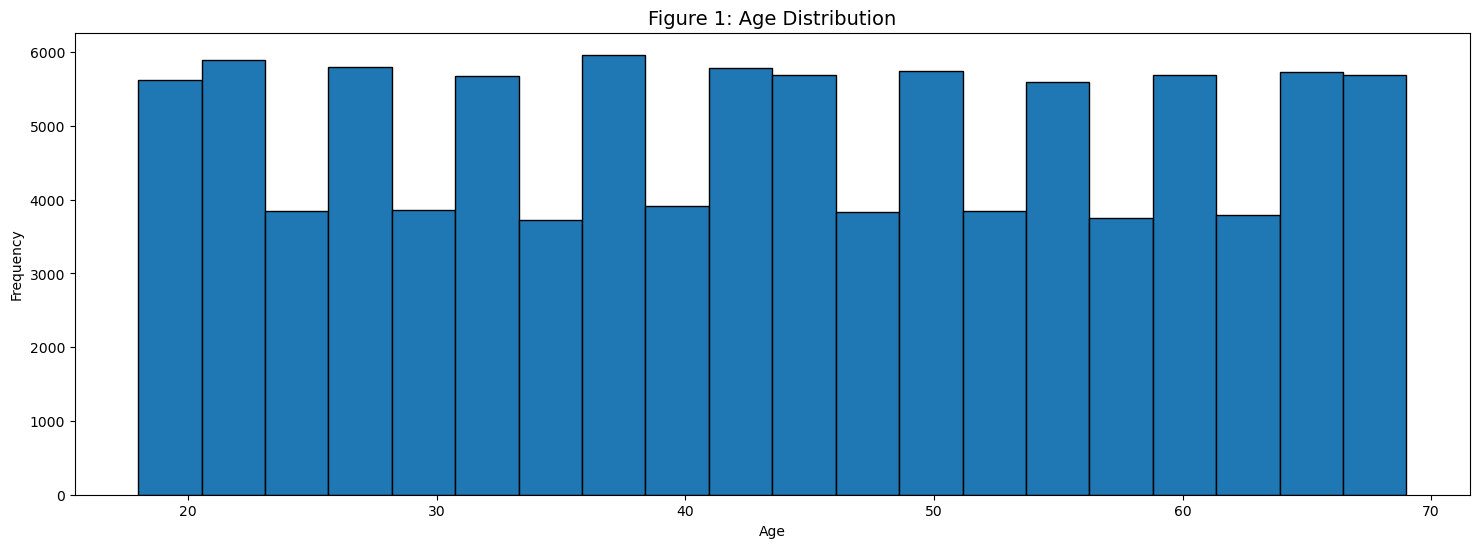

In [20]:
# Age histogram
plt.figure(figsize=(18, 6))
plt.hist(df['age'], bins=20, edgecolor='black')
plt.title('Figure 1: Age Distribution', fontsize=14)
plt.xlabel('Age')
plt.ylabel('Frequency')

**Figure 1 shows that the Age column follows a uniform distribution, where each age within the specified range occurs with equal frequency.**

Text(0, 0.5, 'Frequency')

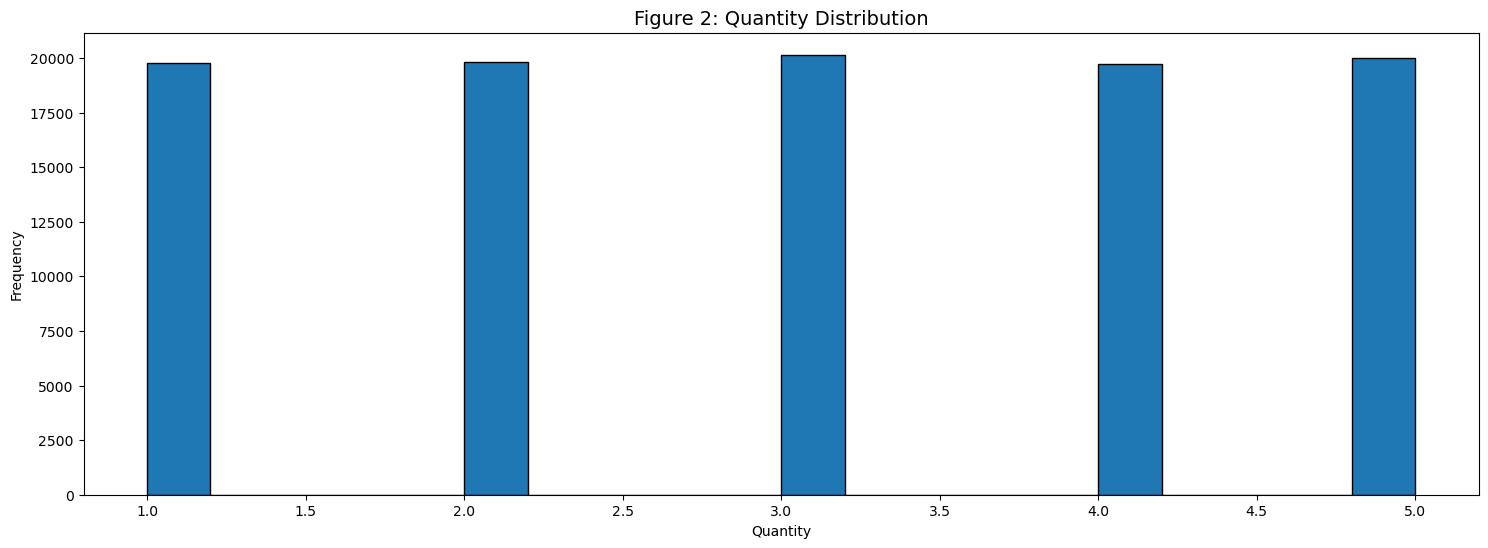

In [21]:
# Quantity histogram
plt.figure(figsize=(18, 6))
plt.hist(df['quantity'], bins=20, edgecolor='black')
plt.title('Figure 2: Quantity Distribution', fontsize=14)
plt.xlabel('Quantity')
plt.ylabel('Frequency')

**As can be seen from Figure 2, the Quantity column follows uniform distribution, each quantity (1 through 5) occurs with the same frequency, which means that every value is equally likely.**

Text(0, 0.5, 'Frequency')

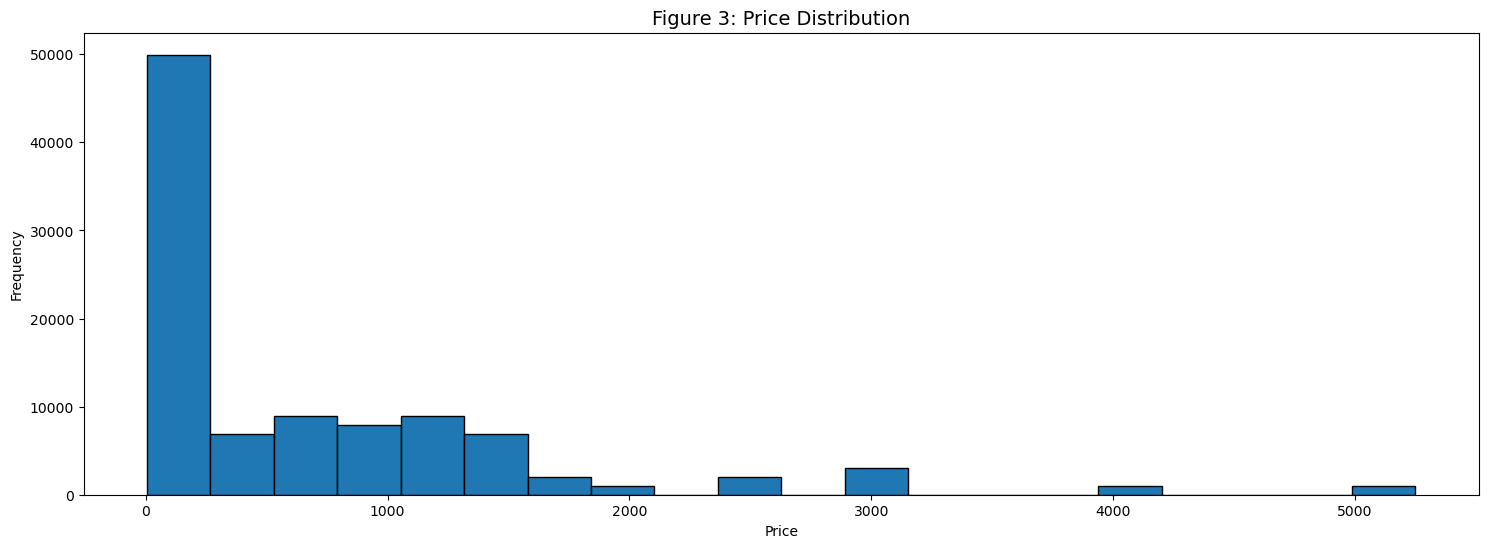

In [22]:
# Price histogram
plt.figure(figsize=(18, 6))
plt.hist(df['price'], bins=20, edgecolor='black')
plt.title('Figure 3: Price Distribution', fontsize=14)
plt.xlabel('Price')
plt.ylabel('Frequency')

**As can be seen from Figure 3, the Price column follows a right-skewed distribution, with most prices concentrated at lower values and a tail extending towards higher prices.**

### 1.6. Calculate skewness

In [23]:
# Calculating skewness before transformation
skewness_age_before = df['age'].skew()
skewness_quantity_before = df['quantity'].skew()
skewness_price_before = df['price'].skew()

print('skewness_age_before: ', skewness_age_before)
print('skewness_quantity_before: ', skewness_quantity_before)
print('skewness_price_before: ', skewness_price_before)

skewness_age_before:  0.0089786298758843
skewness_quantity_before:  -0.0012459535880686293
skewness_price_before:  2.247373625336423


While the skewness of the age and quantity columns falls within an acceptable range, the skewness of the price column does not (2.24 is greater than 1). However, **this high skewness in the price data is acceptable in real life, as some products naturally have higher prices than others. Additionally, transforming the data to correct for this skewness could distort it and affect the accuracy of future analysis. Hence, I will not fix skewness in price column.**

### 1.7.Outliers

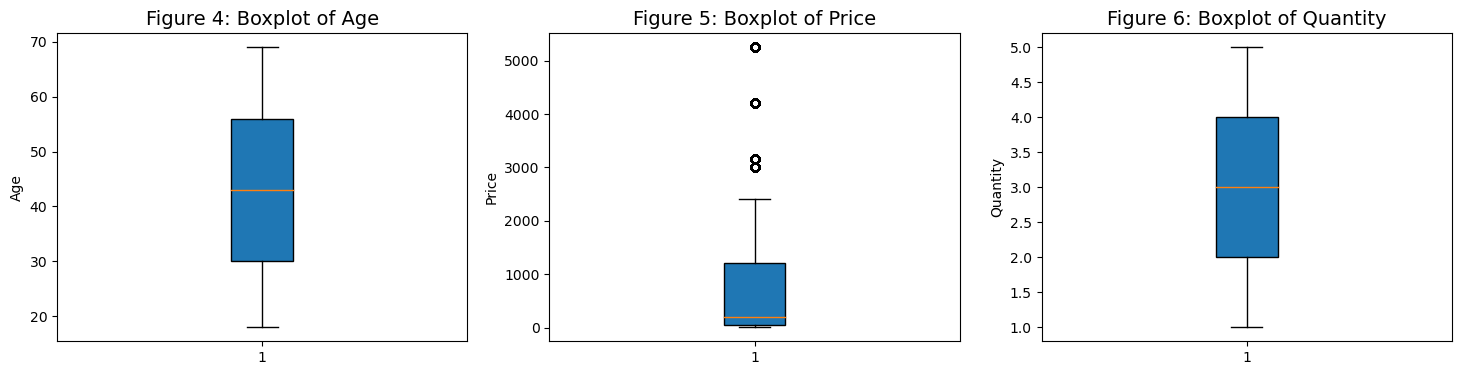

In [24]:
# Create boxplots to identify outliers
plt.figure(figsize=(18, 4))

# Age boxplot
plt.subplot(1, 3, 1)
plt.boxplot(df['age'], patch_artist=True)
plt.title('Figure 4: Boxplot of Age', fontsize=14)
plt.ylabel('Age')

# Price boxplot
plt.subplot(1, 3, 2)
plt.boxplot(df['price'], patch_artist=True)
plt.title('Figure 5: Boxplot of Price', fontsize=14)
plt.ylabel('Price')

# Quantity boxplot
plt.subplot(1, 3, 3)
plt.boxplot(df['quantity'], patch_artist=True)
plt.title('Figure 6: Boxplot of Quantity', fontsize=14)
plt.ylabel('Quantity')

#plt.tight_layout()
plt.show()

**As can be seen from Figure 4,5,6, there are outliers in Price column. I will detect the category of outliers, then choosing suitable approach to solve them.** 

In [25]:
# Find first and third percentile of price column
# Caluclate 25th percentile of price column
percentile25 = df['price'].quantile(0.25)
print('percentile25 of price column:', percentile25)

# Caluclate 75th percentile of price column
percentile75 = df['price'].quantile(0.75)
print('percentile75 of price column:', percentile75)

percentile25 of price column: 45.45
percentile75 of price column: 1200.32


In [26]:
# Calculate interquartile range
iqr = percentile75 - percentile25
print('IQR: ' + str(iqr))

# Calcualte upper and lower thresholds for outliers
upper_limit = percentile75 + 1.5 *iqr
lower_limit = percentile25 - 1.5 * iqr
print('Upper limit of price column:' + str(upper_limit))
print('Lower limit of price column:' + str(lower_limit))

IQR: 1154.87
Upper limit of price column:2932.625
Lower limit of price column:-1686.8549999999998


In [27]:
# Filter the DataFrame to only include rows having outlier in price column
# Assign the filtered results to a variable named "outlier" and display the contents of the variable.
outlier = df[(df['price'] < lower_limit) | (df['price'] > upper_limit)]

# Read general information of 'outlier'
outlier.describe()

,age,quantity,price
count,5024.000000,5024.000000,5024.000000
mean,43.357086,4.399084,3717.856499
std,14.871989,0.801009,885.967884
min,18.000000,3.000000,3000.850000
25%,30.000000,4.000000,3000.850000
50%,43.000000,5.000000,3150.000000
75%,56.000000,5.000000,4200.000000
max,69.000000,5.000000,5250.000000


In [28]:
# Find category of outliers 
outlier['category'].unique().tolist()

['Shoes', 'Technology']

**The category of outliers in price columns are Shoes and Technology.** The price of those ouliers are in range from 2932.625 to 5250 Turkish Liras. **In reality, these values are suitable price for products in Shoes and Technology category, so I will keep outliers.**

### 1.8. Data type conversion 

In [29]:
# Filter the DataFrame to only include rows having incorrect invoice_date format
# Assign the filtered results to a variable named "short_date_values" and display the contents of the variable.
short_date_values = df[df['invoice_date'].str.len()<6]
short_date_values

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
13,I179802,C312861,Male,25,Clothing,2,600.16,Cash,44882,Cevahir AVM
30,I161949,C159164,Female,66,Toys,3,107.52,Debit Card,44746,Mall of Istanbul
49,I304265,C653385,Female,22,Books,5,75.75,Debit Card,44360,Forum Istanbul
112,I299820,C820515,Female,22,Books,3,45.45,Cash,44522,Kanyon
236,I218385,C290280,Female,51,Toys,1,35.84,Cash,44761,Metrocity
249,I120948,C340089,Female,54,Shoes,4,2400.68,Debit Card,44416,Mall of Istanbul
353,I508712,C216619,Female,64,Toys,3,107.52,Credit Card,44761,Mall of Istanbul
53518,I226929,C185726,Female,43,Cosmetics,3,121.98,Cash,44576,Cevahir AVM
53519,I303174,C305002,Female,20,Technology,1,1050.00,Cash,44222,Istinye Park
53539,I291878,C119087,Male,49,Toys,3,107.52,Cash,44534,Emaar Square Mall


In [30]:
# Convert data type in 'invoice_date' column from string to numeric
short_date_values['invoice_date'] = pd.to_numeric(short_date_values['invoice_date'])

C:\Users\Nguyen Thu Uyen\AppData\Local\Temp\ipykernel_27456\1675724338.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  short_date_values['invoice_date'] = pd.to_numeric(short_date_values['invoice_date'])


In [31]:
# Convert the 'invoice_date' column from numeric days to a datetime format.
short_date_values['invoice_date'] = pd.to_datetime(short_date_values['invoice_date'], origin='1899-12-30', unit='D')

# Print the DataFrame to check the conversion and verify the 'invoice_date' column has been correctly formatted.
print(short_date_values['invoice_date'])

13      2022-11-17
30      2022-07-04
49      2021-06-13
112     2021-11-22
236     2022-07-19
249     2021-08-08
353     2022-07-19
53518   2022-01-15
53519   2021-01-26
53539   2021-12-04
76666   2021-11-13
76687   2022-01-14
76781   2021-05-20
99389   2022-08-14
99418   2022-02-05
Name: invoice_date, dtype: datetime64[ns]


C:\Users\Nguyen Thu Uyen\AppData\Local\Temp\ipykernel_27456\3309707707.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  short_date_values['invoice_date'] = pd.to_datetime(short_date_values['invoice_date'], origin='1899-12-30', unit='D')


In [32]:
# Now replace the invoice_date in df with the corrected dates from short_date_values
df.loc[short_date_values.index, 'invoice_date'] = short_date_values['invoice_date']

# Convert to date time
df['invoice_date'] = pd.to_datetime(df['invoice_date'])

In [33]:
# Check date after being converted
df.iloc[13]

invoice_no                    I179802
customer_id                   C312861
gender                           Male
age                                25
category                     Clothing
quantity                            2
price                          600.16
payment_method                   Cash
invoice_date      2022-11-17 00:00:00
shopping_mall             Cevahir AVM
Name: 13, dtype: object

## SECTION 2: ANALYSIS

To better understand Dibs' customers and identify behavioral patterns and trends, I will **analyze revenue by category** to focus marketing campaigns effectively. Additionally, I will examine the **correlation between customer age and spending** to gain insights into how age influences spending behavior. By further **analyzing spending across different age groups**, I will be able to design targeted marketing promotions tailored to specific age demographics.

### 2.1. Sales analysis by categories

In [34]:
# I will analyze sales by category to recommend 
# which categories Dibs should focus on for its marketing campaigns.

In [35]:
# Create a revenue column to measure the sales of each categories
df['revenue'] = df['quantity'] * df['price']

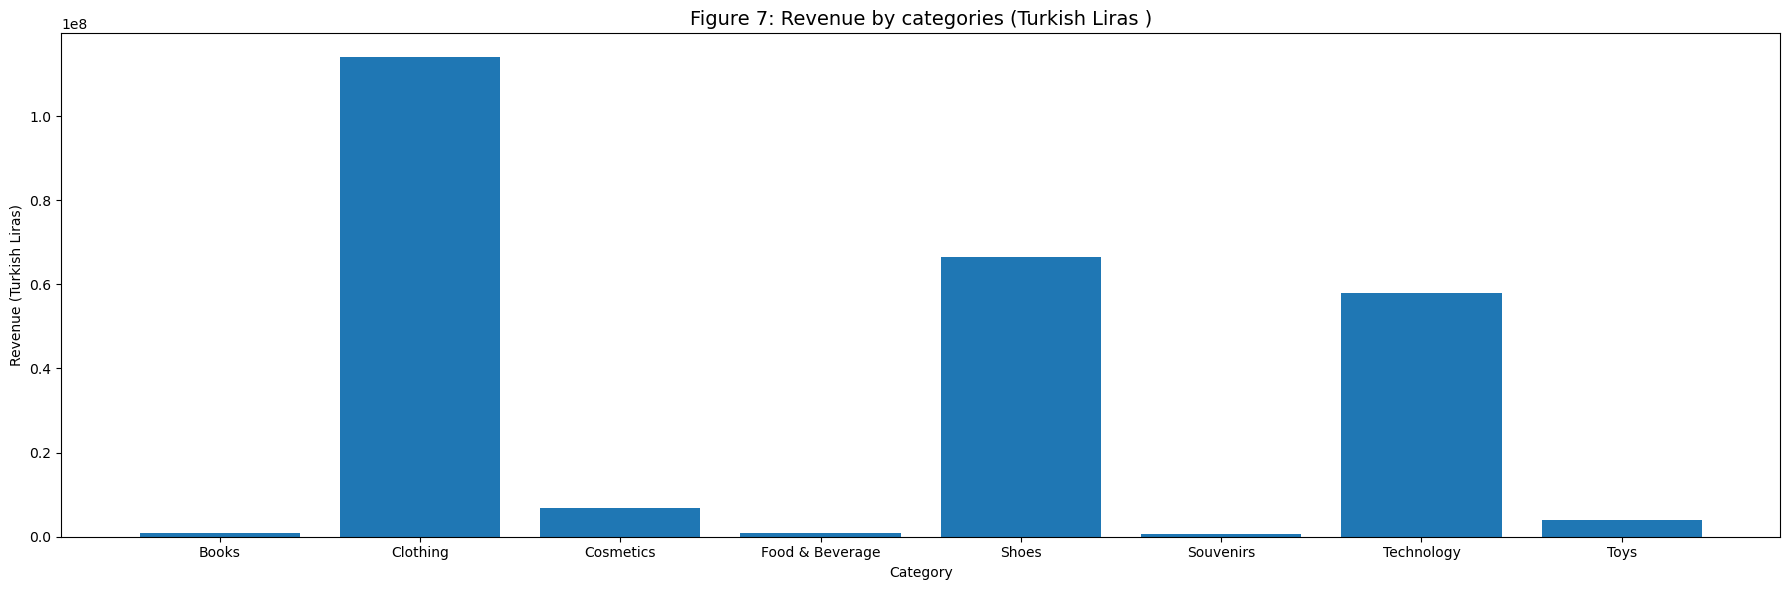

In [36]:
# Group revenue by category
revenue_by_category = df.groupby('category')['revenue'].sum()

# Draw bar chart for revenue by categories
plt.figure(figsize=(18, 6))
plt.bar(x=revenue_by_category.index, height=revenue_by_category.values, label="revenue per category")
plt.title('Figure 7: Revenue by categories (Turkish Liras )', fontsize = 14)
plt.xlabel('Category')
plt.ylabel('Revenue (Turkish Liras)')
plt.xticks(rotation=360)

plt.tight_layout()
plt.show()


Figure 7 highlights that **Clothing, Shoes, and Technology are the top three revenue-generating categories for Dibs, while Books, Food & Beverage, and Souvenirs generate the least revenue.** To sustain its revenue stream and customer loyalty, Dibs should **continue launching marketing campaigns for the top three categories.** Additionally, Dibs should **intensify its marketing efforts in the lower-performing categories**—Books, Food & Beverage, and Souvenirs—to boost overall sales and attract more customers in these segments.

Dibs can **launch marketing campaigns targeting Clothing, Shoes, and Technology** to maintain revenue and enhance customer loyalty:

- Loyalty Programs: Dibs can provide exclusive offers, early access to new arrivals for long-term members, and special perks for loyal customers who make repeat purchases.
- Seasonal Promotions: Dibs should take advantage of major shopping seasons such as back-to-school, holidays, and Black Friday to boost sales and keep customers engaged with fresh, timely deals.
- Omnichannel Experience: Dibs can offer a seamless shopping journey across all platforms, both online and in-store, by providing services like click-and-collect, hassle-free returns, and uniform pricing.
- Influencer Collaborations: Dibs can collaborate with influencers whose values align with the brand to authentically showcase products through engaging content like fashion styling tips or tech tutorials, helping to reach a broader audience and build trust.


**To increase overall sales and attract more customers in the Books, Food & Beverage, and Souvenirs categories, identifying the target age group for each of these categories is crucial.** Understanding the demographics of Dibs' customers allows it for tailored marketing strategies that resonate with specific age groups, ultimately driving more engagement and sales.

In [37]:
# Define age groups
age_bins = [18, 25, 35, 45, 55, float('inf')]
age_labels = ['18-25', '26-35', '36-45', '46-55', '56+']
df['age_group'] = pd.cut(df['age'], bins=age_bins, labels=age_labels, right=False)

# Identify top three categories with the least revenue
least_revenue_categories = ['Books', 'Food & Beverage', 'Souvenirs']

# Filter data for the least revenue categories
filtered_data = df[df['category'].isin(least_revenue_categories)]

# Aggregate revenue by age group within the least revenue categories
revenue_by_age_group = filtered_data.groupby(['age_group', 'category'])['revenue'].sum().reset_index()

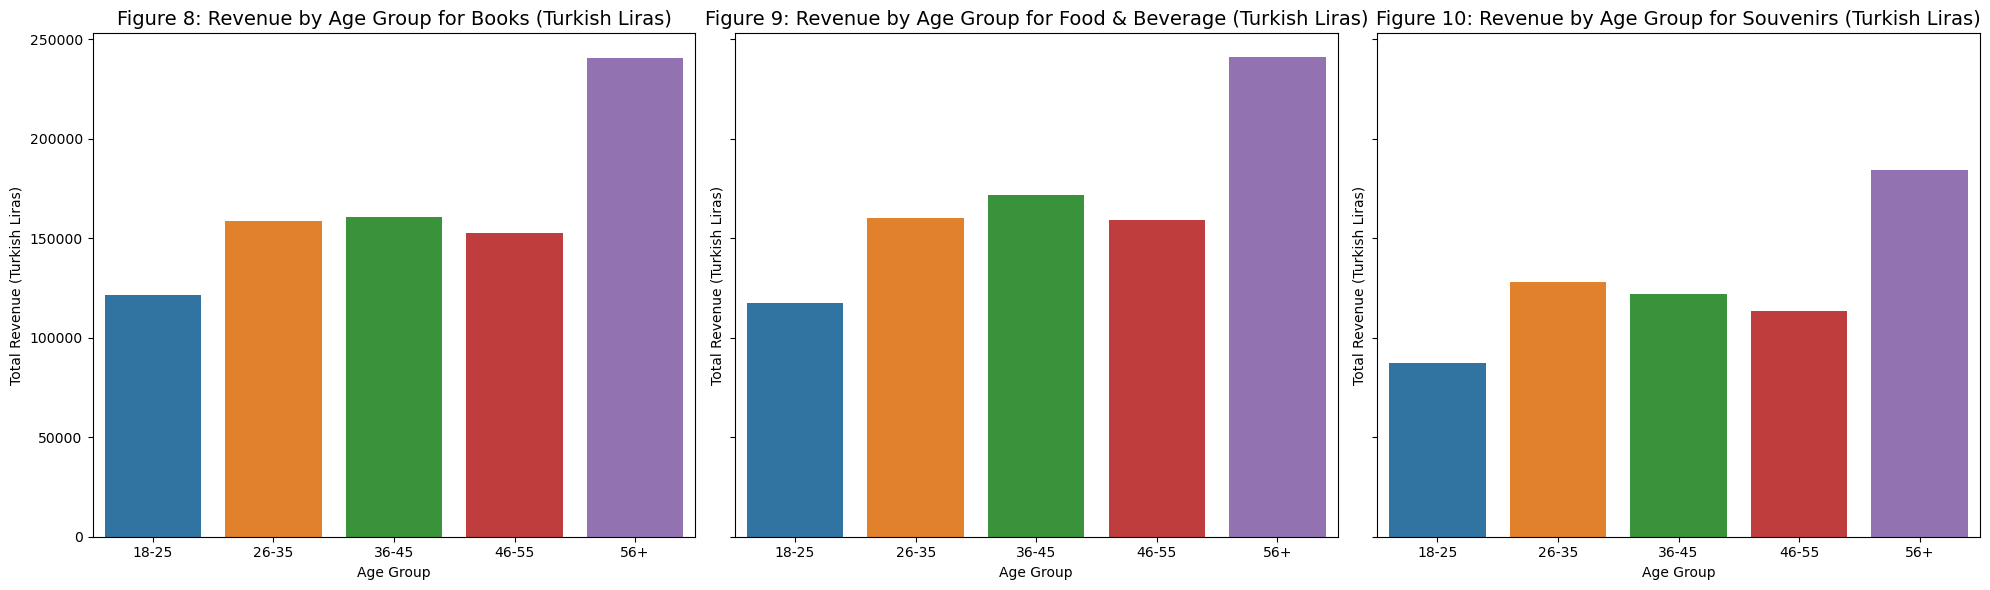

In [38]:
# Set up the plot grid
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)

# List of figure numbers
figure_numbers = [8, 9, 10]

for ax, category, fig_num in zip(axes, least_revenue_categories, figure_numbers):
    category_data = revenue_by_age_group[revenue_by_age_group['category'] == category]
    sns.barplot(data=category_data, x='age_group', y='revenue', ax=ax)
    ax.set_title(f'Figure {fig_num}: Revenue by Age Group for {category} (Turkish Liras)', fontsize=14)
    ax.set_xlabel('Age Group')
    ax.set_ylabel('Total Revenue (Turkish Liras)')

plt.tight_layout()
plt.show()

**Summary**

Over 56+ customers are the main customers generating most revenue for Books, Food & Beverage, and Souvenirs for Dibs. 
Customers in age group 18-25 spend least for 3 categories. 

**Marketing strategies**

I suggest Dibs should focus its marketing efforts on the 26-35 and 36-45 age groups, as these customers have stable incomes and a strong purchasing power, making them more likely to spend on lifestyle and family-oriented products. The 18-25 age group, with limited disposable income, and the 46-55 age group, focused on saving for retirement, are less likely to contribute significantly to sales. 

**Age Group: 26-35**
- Books:
    - Create advertising on social media for books related to career growth, self-help, and productivity.
    - Create subscription boxes campaign that deliver a curated selection of books based on their interests. 

- Food & Beverage:
    - Cooperate with wellness influencers to advertise meal kits with quick, easy-to-follow recipes that cater to busy lifestyles, focusing on gourmet and international cuisines. 
    - Create Loyalty Programs: Develop loyalty programs that reward frequent purchases, particularly for busy professionals who appreciate consistency and value.

- Souvenirs:
    - Cooperate with travel bloggers to advertise souvenir items and gift items in holiday seasons and special occasions.  

**Age Group: 36-45** 
- Books:
    - Create advertising on social media for books focused on parenting, family activities, and educational resources for children.
    - Offer special discounts or promotions for family or group purchases.

- Food & Beverage:
    - Launch family-sized food and beverage options, focusing more on nutritional benefits.

- Souvenirs:
    - Create souvenirs that help capture family memories, such as photo frames, albums, or custom family portraits.

### 2.2. Correlation between age and spending

In [39]:
# I will create a scatter plot to visualise the relationship between age and spending, 
# and provide insights from this visualization. 

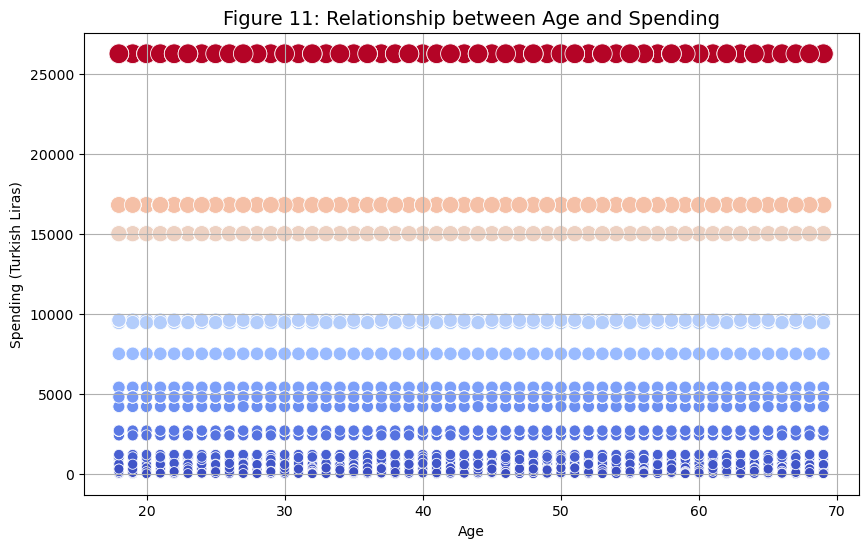

In [40]:
# Create a scatter plot using seaborn
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='age', y='revenue', hue='revenue', palette='coolwarm', size='revenue', sizes=(50, 200), legend=None)
plt.xlabel('Age')
plt.ylabel('Spending (Turkish Liras)')
plt.title('Figure 11: Relationship between Age and Spending', fontsize = 14)
plt.grid(True)

plt.show()

**Correlation**

The visualization shows that **there is no clear correlation between age and spending.** Customers of all ages are found across various spending levels.

**Summary**

According to Figure 11, customers fall into clear spending tiers:

- Some spend slightly more than 25,000 Turkish Liras.
- Others spend between 15,000 and 17,000 Turkish Liras.
- Most spend less than 10,000 Turkish Liras.

**Based on these summary, Dibs can execute segmented marketing campaigns such as:**
- Offer special deals or loyalty rewards for high spenders, regardless of their age.
- Implement a "Buy More, Save More" campaign where customers get bigger discounts when their total purchase amount increases.
- Create unique memberships for different spending levels, giving members exclusive access to new products, events, or personalized offers.

### 2.3. Spending analysis by age group

In [41]:
# I will segment the customers into different age groups (e.g., 18-25, 26-35, 36-45, 46-55, 56+) 
# to find out how spending score varies across these age groups.  

**The spending score represents the total expenditure by customers, which equals to Dibs's revenue.**

In [42]:
# I have segmented customers into different age group in 2.1. Sales analysis by categories
# Group spending by 'age_group' and aggregate the required statistics
spending_by_age_group = df.groupby('age_group').agg(
    # Count the number of people in each age group
    number_of_people=('age', 'size'),  
     # Sum of revenue in each age group
    total_spending=('revenue', 'sum'),  
    # Average revenue in each age group
    average_spending=('revenue', 'mean')).reset_index()

# Display the grouped DataFrame
print(spending_by_age_group)

  age_group  number_of_people  total_spending  average_spending
0     18-25             13495     33449282.59       2478.642652
1     26-35             19080     47804464.96       2505.475103
2     36-45             19402     50077087.37       2581.027078
3     46-55             19051     48413263.93       2541.245285
4       56+             28429     71761127.91       2524.222727


Because the 56+ age group has the highest total number of individuals, it has highest total spending. Consequently, using total spending alone is not effective for comparing spending across age groups. Instead, **I will use the average spending per person to identify which age group spends the most.**

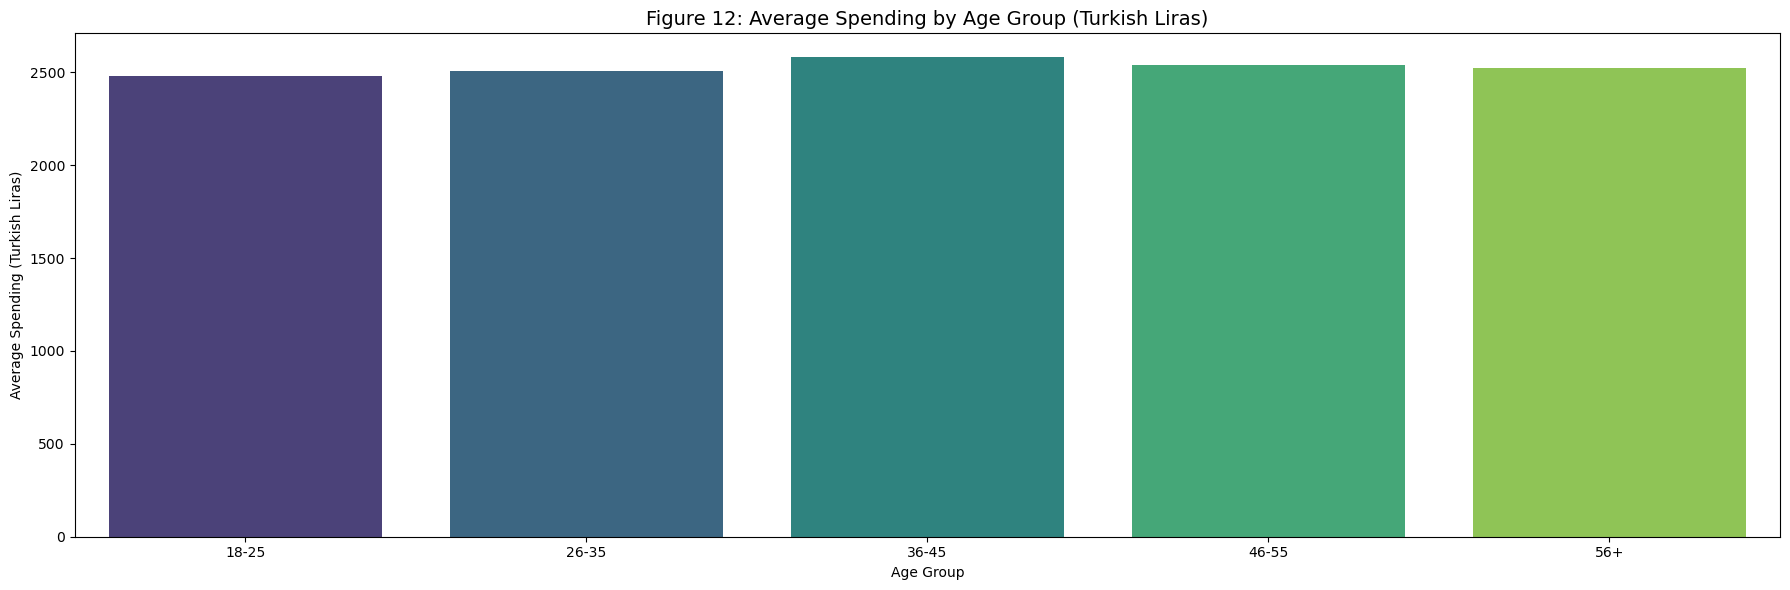

In [43]:
# Create a bar plot with seaborn
plt.figure(figsize=(18, 6))
sns.barplot(x='age_group', y='average_spending', data=spending_by_age_group, palette='viridis')
plt.xlabel('Age Group')
plt.ylabel('Average Spending (Turkish Liras)')
plt.title('Figure 12: Average Spending by Age Group (Turkish Liras)', fontsize = 14)


plt.tight_layout()
plt.show()

**Summary**

The 36-45 age group has the highest average spending at approximately 2,581 Turkish Liras, which is about 4.1% higher than the 18-25 age group’s average spending of 2,479 Turkish Liras. The spending levels for the 46-55 age group (2,541 Turkish Liras), those over 55 (2,524 Turkish liras), and individuals in their early to mid-30s are relatively close, with differences ranging from 1.5% to 2.2% compared to the 36-45 age group.

**Based on these summary, Dibs can execute targeted marketing strategies such as:**

- Providing promotions or discounts to the 18-25 age group to boost their average expenditure.
- Designing high-end products or services tailored for the 36-45 age group to leverage their strong spending capacity.
- Implementing loyalty programs targeting the 46-55 age group to foster repeat purchases and customer retention.
- Launching initiatives focused on the 56+ age group to cater to their specific needs and preferences, potentially enhancing their engagement and spending.

## SECTION 3: RECOMMENDATION

### 3.1. Sales by Payment Method


In [44]:
# I will create a visualisation to visualize the proportion of total sales made by each payment_method
# to find out customer preferences for payment methods 
# and provide actionable recommendations for Dibs. 

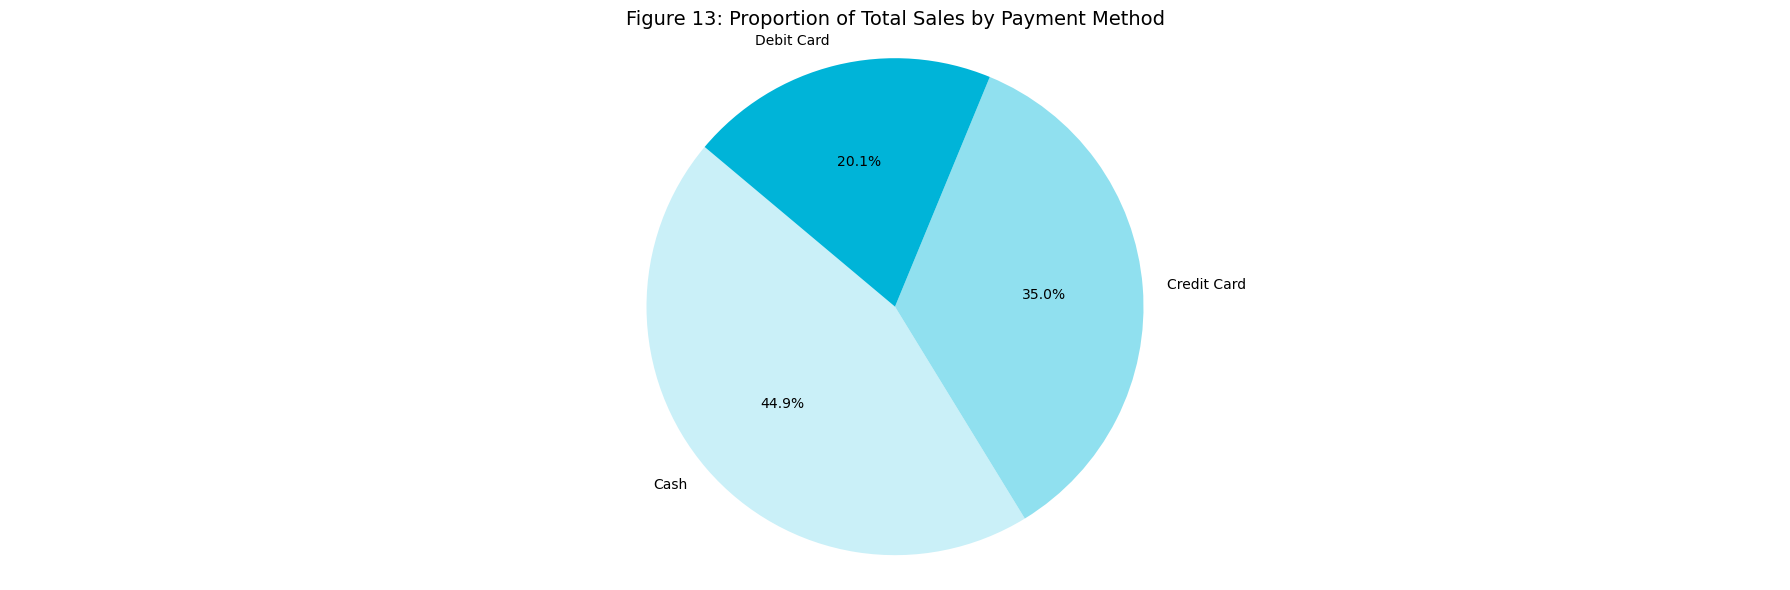

In [45]:
# Group revenue by 'payment_method' and aggregate total revenue
payment_method_revenue = df.groupby('payment_method')['revenue'].sum().reset_index()

# Plotting using matplotlib
plt.figure(figsize=(18, 6))
plt.pie(payment_method_revenue['revenue'], labels=payment_method_revenue['payment_method'], autopct='%1.1f%%', startangle=140, colors=['#caf0f8','#90e0ef','#00b4d8','#ffcc99'])
plt.title('Figure 13: Proportion of Total Sales by Payment Method', fontsize = 14)
plt.axis('equal')

# Display the plot
plt.tight_layout()
plt.show()

**Summary**

Cash is the most common payment method, representing nearly 45% of transactions. Credit cards are the second most popular, while debit cards are the least preferred.

**Recommendations**

- Dibs should ensure adequate cash reserves with various denominations daily to enhance the customer experience.
- To encourage credit and debit card usage, Dibs can:
    - Partner with banks to offer rewards like cashback or points.
    - Provide flexible payment options such as installment plans, Buy Now Pay Later.
    - Increase membership points or create promotions for card payments.
- Dibs should maintain and upgrade its payment process to ensure accuracy and convenience across payment methods.

### 3.2. Sales Trend Over Time

In [46]:
# I will create a line chart to visualize the total monthly sales over the period covered by the dataset, 
# then provide actionable recommendations for Dibs from visualization. 

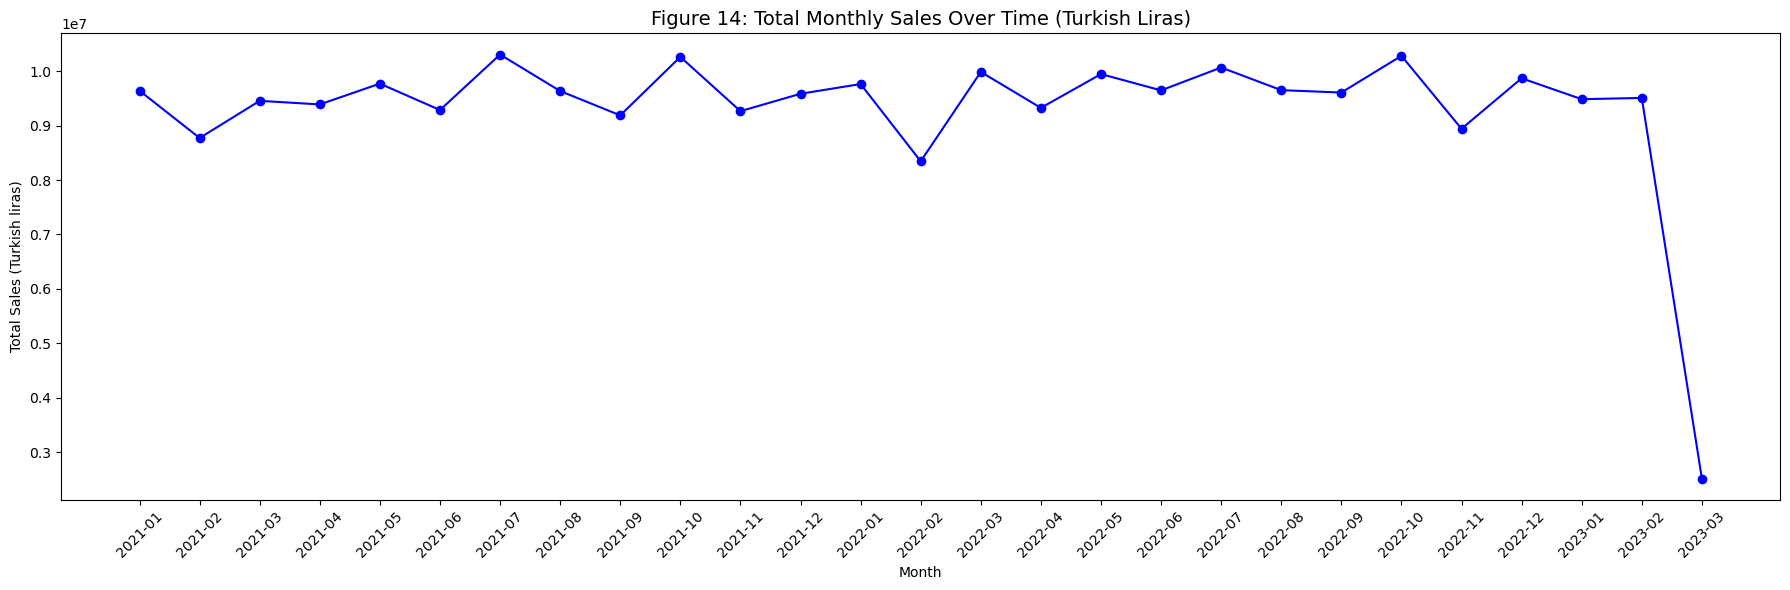

In [47]:
# Extract year and month from 'invoice_date'
df['year_month'] = df['invoice_date'].dt.to_period('M')

# Group revenue by 'year_month' and aggregate total revenue
monthly_sales = df.groupby('year_month')['revenue'].sum().reset_index()

# Plotting using matplotlib
plt.figure(figsize=(18, 6))
plt.plot(monthly_sales['year_month'].astype(str), monthly_sales['revenue'], marker='o', linestyle='-', color='b')
plt.xlabel('Month')
plt.ylabel('Total Sales (Turkish liras)')
plt.title('Figure 14: Total Monthly Sales Over Time (Turkish Liras)', fontsize=14)
plt.xticks(rotation=45)  # Rotate x labels for better readability

# Display the plot
plt.tight_layout()
plt.show()

In [48]:
latest_date = df['invoice_date'].max()
print("The latest invoice date is:", latest_date)

The latest invoice date is: 2023-03-08 00:00:00


**Summary** 

Monthly sales have fluctuated over time. It peaked in July and October and dropped in February. As data was collected only until March 8th, 2023, there is a significant decline in sales of March 2023. 

**Recommendations**

- Maximize sales during strong months like July and October with special promotions (limited-time offers and flash sales), product launches, and loyalty rewards.
- Strengthen holiday campaigns in November-December with early-bird deals and gift cards to sustain high performance.
- Create Budget-Friendly Promotions, offering Buy Now, Pay Later to encourage spending after the holiday season in February.